In [1]:
import importlib 
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))
import utils.dataset
importlib.reload(utils.dataset)
from utils.dataset import *
from utils.dna import Genes

In [2]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
# medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
# template = create_template_from_genes(medium_geneset.dna)
f1 = 'gene_forehead_brow_height.forehead_brow_height_pos'
f2 = 'skin_color[1]'
dir = DATA_DIR / "genes_grid" / f"{f1}_{f2}"

In [4]:
template

{'hair_color[0]': 93,
 'hair_color[1]': 220,
 'hair_color[2]': 93,
 'hair_color[3]': 220,
 'skin_color[0]': 131,
 'skin_color[1]': 154,
 'skin_color[2]': 131,
 'skin_color[3]': 154,
 'eye_color[0]': 87,
 'eye_color[1]': 218,
 'eye_color[2]': 87,
 'eye_color[3]': 218,
 'gene_chin_forward.chin_forward_pos': 127,
 'gene_chin_height.chin_height_pos': 127,
 'gene_chin_width.chin_width_pos': 127,
 'gene_eye_angle.eye_angle_pos': 126,
 'gene_eye_depth.eye_depth_pos': 139,
 'gene_eye_height.eye_height_pos': 115,
 'gene_eye_distance.eye_distance_pos': 132,
 'gene_eye_shut.eye_shut_pos': 131,
 'gene_forehead_angle.forehead_angle_pos': 103,
 'gene_forehead_brow_height.forehead_brow_height_pos': 141,
 'gene_forehead_roundness.forehead_roundness_pos': 162,
 'gene_forehead_width.forehead_width_pos': 127,
 'gene_forehead_height.forehead_height_pos': 125,
 'gene_head_height.head_height_pos': 126,
 'gene_head_width.head_width_pos': 136,
 'gene_head_profile.head_profile_pos': 132,
 'gene_head_top_height

In [5]:
import itertools as it 

def generate_genes_grid(template, gene1, gene2, step=5):
    for v1, v2 in it.product(range(0, 255, step), range(0, 255, step)):
        genes = template.copy()
        genes[gene1] = v1
        genes[gene2] = v2
        yield genes

genes = list(generate_genes_grid(template, f1, f2))
print(len(genes))

2601


In [3]:
dir = DATA_DIR / "genes_grid" / f"{f1}_{f2}"
# dir.mkdir(parents=True, exist_ok=True)

# for i, g in enumerate(genes):
#     gene = Genes(**Genes.unflatten(g))
#     (dir / f"{i}.txt").write_text(gene.to_ck_string())

# Visualize 

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 692.79it/s]


arcface-r100


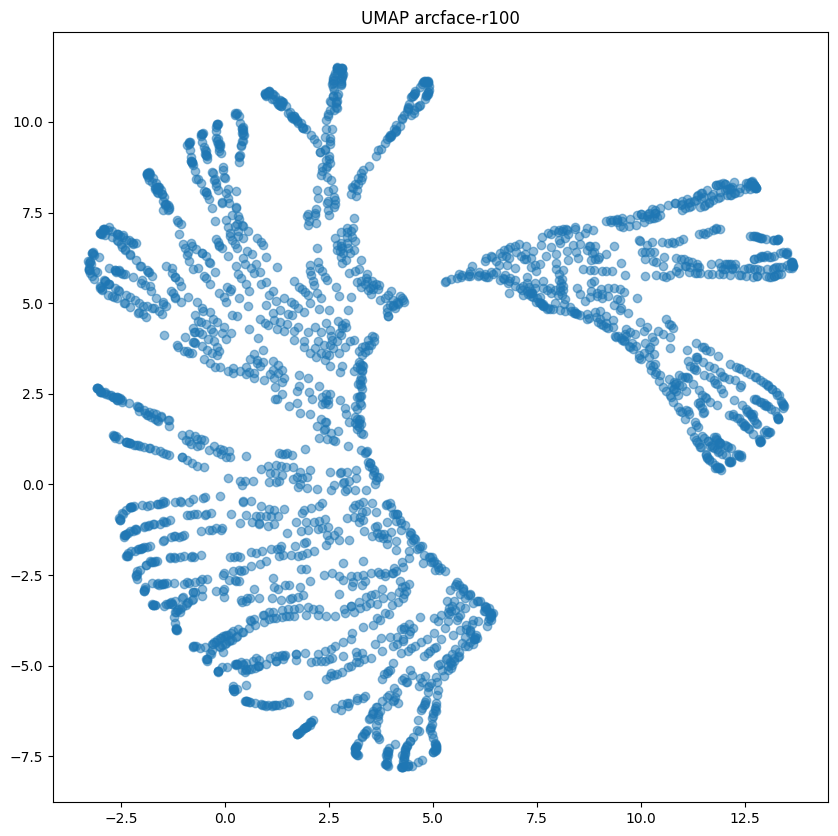

layer1-2-bn3


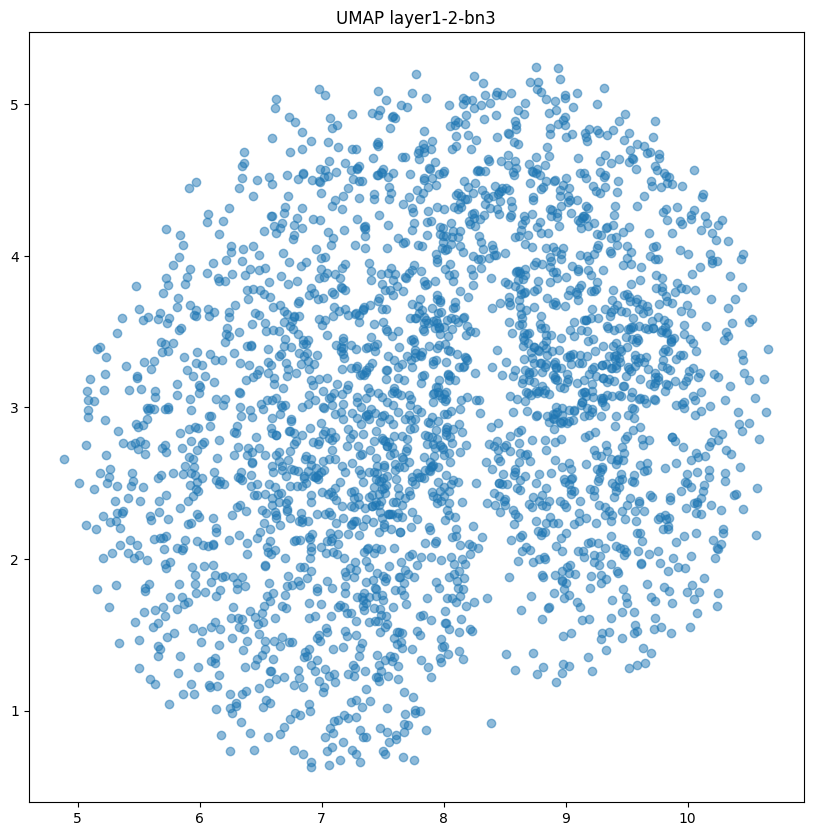

layer2-12-bn3


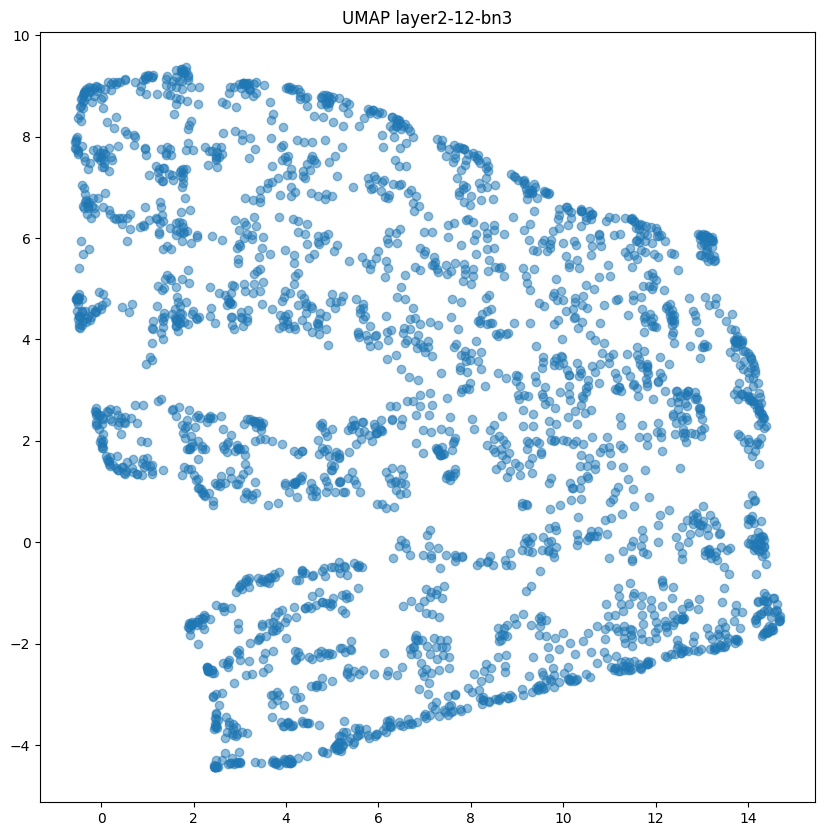

layer3-29-bn3


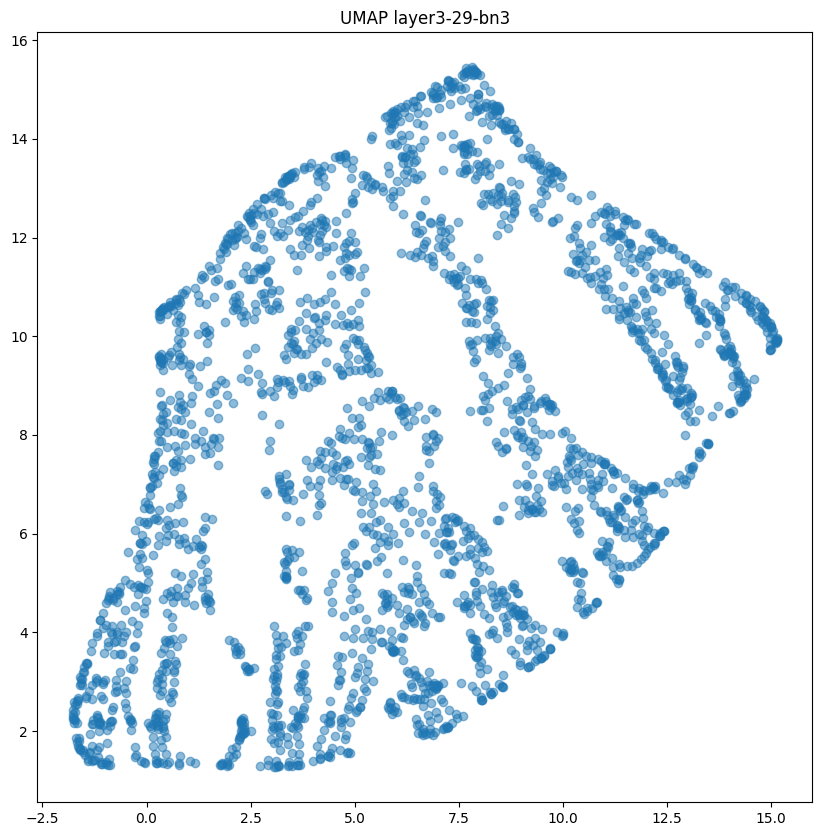

layer4-2-bn3


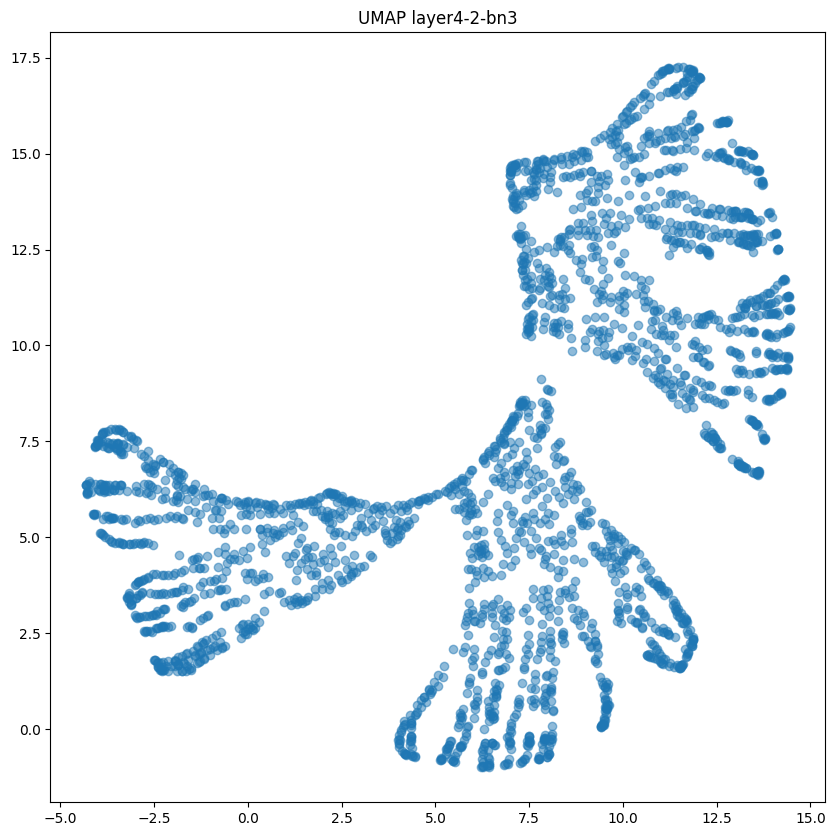

In [4]:
grid_dataset = ProcessedDataset(DATA_DIR / "genes_grid" / f"{f1}_{f2}_embeddings")

# visualize with umap, pca and tsne 
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_embedding(embedding, title):
    plt.figure(figsize=(10, 10))
    plt.scatter(embedding[:, 0], embedding[:, 1], alpha=0.5)
    plt.title(title)
    plt.show()

emb_names = sorted(list(grid_dataset.model2normalized_embeddings.keys()))
for emb_name in emb_names:
    embeddings = grid_dataset.model2normalized_embeddings[emb_name]
    print(emb_name)
    plot_embedding(umap.UMAP().fit_transform(embeddings), f"UMAP {emb_name}")
    # plot_embedding(PCA(n_components=2).fit_transform(embeddings), f"PCA {emb_name}")
    # plot_embedding(TSNE(n_components=2).fit_transform(embeddings), f"TSNE {emb_name}")